In [1]:
import pandas as pd
import numpy as np

jahr = '2024'

if jahr == '2025':
    wetter_csv='Wetter/2024_Wetter_Station_020_Mengen_hh24.csv'
else:
    wetter_csv='Wetter/2024_Stunde_077_Hartheim.csv'

wetter=pd.read_csv(wetter_csv,sep=';',decimal=',')
wetter['Datum']=pd.to_datetime(wetter['Tag']+' '+wetter['Stunde'],format='%d.%m.%Y %H:%M',utc=True)
wetter=wetter.set_index('Datum')

In [2]:
Windkraft_je_ms=pd.read_csv('Windanlagen_kw_pro_ms.csv',sep=';')
Windkraft_je_ms['max W/m²']=Windkraft_je_ms.apply(lambda row: pow(min(row['m/s'],15),3)*0.5*1.2, axis= 1)
Windkraft_je_ms['m/s cp']=Windkraft_je_ms['m/s']
Windkraft_je_ms.set_index('m/s',drop=True,inplace=True)
Windkraft_je_ms['rel_V172-7.2']=Windkraft_je_ms['V172-7.2']/Windkraft_je_ms['V172-7.2'].max()
#Windkraft_je_ms.head()

In [3]:
faktor=5.7
# Basis Eki
basis=wetter['MAX_WV200max']
# Basis Helgoland
#basis=preis_menge['Wind Helgoland']
#faktor=11.6
fak='{}'.format(faktor)
fak_halbe='{}'.format(faktor/2)
max_wind=500
wetter['Wind '+fak+' m/s']=round(faktor*basis/basis.mean()*2)/2
wetter['Wind '+fak+' m/s']=wetter.apply(lambda row: min(row['Wind '+fak+' m/s'],max_wind),axis= 1)

wetter['max W/m²']=wetter.apply(lambda row: pow(min(row['Wind '+fak+' m/s'],15),3)*0.5*1.2, axis= 1)
wetter['pow H'+fak+' V172']=wetter['Wind '+fak+' m/s'].map(Windkraft_je_ms['rel_V172-7.2'])

wetter['pow H'+fak+' V172']=wetter['pow H'+fak+' V172'].fillna(0)
wetter['z Anzahl']=1

In [5]:
waermebedarf=0.066 # kWh/h*K
# unter 22°C - 
pv_prod=67/5000 # 60kWh pro 5000 Globalstrahlung
pv_prod=pv_prod   # halbierung wegen Wind
wind_pow=0*3         # 3 kW Anteilige Leistung

In [6]:
wetter['PV']=pv_prod*wetter['SUM_GS200']
#Windkraft_je_ms['max W/m²']=Windkraft_je_ms.apply(lambda row: pow(min(row['m/s'],15),3)*0.5*1.2, axis= 1)
wetter['WP']=wetter.apply(lambda row: max(22-row['AVG_TA200'],0.5)*waermebedarf, axis=1)
wetter['Wind']=wetter['pow H'+fak+' V172']*wind_pow
wetter['Haus']=0.35
wetter['delta']=wetter['PV']+wetter['Wind']-wetter['WP']-wetter['Haus']

In [55]:
r_arr=[]
liste=[0,1,2,3,4,5,6,7,8,9,10,12,15,20,21,22,23,24,25,26,50,75,80,100,500,2599,2600,2700]
#liste=[1,15,100]

start_time = time.time()
#for speicherkap in():
for speicherkap in liste:
    speicher_alt=0
    #speicherkap=100
    wetter['Speicher']=0.0
    wetter['VerbrauchSpeicher']=0.0
    
    for cur in range(2):
        a_speicher=[]
        a_verbrauchspeicher=[]
        a_einspeicher=[]
        
        for index, row in wetter.iterrows():
            idx=index
    
            
            
            #rw=wetter.iloc[idx]
            delta=row['PV']+row['Wind']-row['WP']-row['Haus']
            #delta=row.iloc[11]+row.iloc[13]-row.iloc[12]-row.iloc[14]
    
            speicher_neu=max(min(speicherkap,delta+speicher_alt),0)
    
            verbrauch=max(speicher_alt-speicher_neu,0)
            einspeicher=min(speicher_alt-speicher_neu,0)
            
            a_speicher.append(speicher_neu)
            a_verbrauchspeicher.append(verbrauch)
            a_einspeicher.append(einspeicher)
            speicher_alt=speicher_neu
        wetter['VerbrauchSpeicher']=a_verbrauchspeicher
        wetter['Einspeicher']=a_einspeicher
        wetter['Speicher']=a_speicher

    wetter['Netz +']=wetter.apply(lambda row: max(row['WP']+row['Haus']-row['PV']-row['Wind']-row['VerbrauchSpeicher']-row['Einspeicher'],0), axis=1)
    wetter['Netz -']=wetter.apply(lambda row: min(row['WP']+row['Haus']-row['PV']-row['Wind']-row['VerbrauchSpeicher']-row['Einspeicher'],0), axis=1)
    wetter=wetter.round(6)
    r_arr.append([speicherkap,wetter['VerbrauchSpeicher'].sum()])
print("--- %s seconds ---" % (time.time() - start_time))    

--- 33.8344943523407 seconds ---


In [8]:
df=wetter.reset_index()
df['Monat']=df['Datum'].dt.month
df['Jahr']=df['Datum'].dt.year

agf={'PV':'sum','WP':'sum','Haus':'sum','Wind':'sum','Netz +':'sum','Netz -':'sum','VerbrauchSpeicher':'sum','Einspeicher':'sum','Speicher':["min", "max"]}
cols=['PV','WP','Haus','Wind','Netz +','Netz -','VerbrauchSpeicher','Einspeicher','Speicher']
res=pd.pivot_table(df,index='Monat',values=cols, aggfunc=agf)

#pd.pivot_table(df,index='Monat',values=['PV','WP','Haus','Wind','Netz +','Netz -','VerbrauchSpeicher','Einspeicher','Speicher'], aggfunc={'PV':'sum','Speicher':('max','min')},margins=True,margins_name=jahr)

In [9]:
res

Einspeicher   Haus Netz +      Netz -          PV    Speicher  \
              sum    sum    sum         sum         sum         max   
Monat                                                                 
1      -153.29468  260.4    0.0     0.00000   396.44704  1129.37494   
2      -395.99500  243.6    0.0     0.00000   662.43972   355.67004   
3      -821.21082  260.4    0.0     0.00000  1144.19250   426.49926   
4     -1172.92146  252.0    0.0     0.00000  1503.75470  1159.20996   
5     -1700.11518  260.4    0.0     0.00000  1989.53150  2555.08306   
6      -355.56266  252.0    0.0 -1553.48606  2136.25212  2700.00000   
7      -191.83600  260.4    0.0 -2013.85392  2411.94640  2700.00000   
8      -198.13136  260.4    0.0 -1947.22358  2325.91438  2700.00000   
9      -342.96942  252.0    0.0  -663.29582  1223.90374  2700.00000   
10     -446.47472  260.4    0.0   -21.69712   698.17886  2700.00000   
11     -133.05662  252.0    0.0     0.00000   364.53494  2659.08944   
12      -71.29448  260.4    0.0     0.00000   298.39120  2010.06940   

                  VerbrauchSpeicher        WP Wind  
              min               sum       sum  sum  
Monat                                               
1       346.19694         927.05104  909.8034  0.0  
2       131.10046         585.78088  608.6256  0.0  
3       107.03224         566.74812  629.3298  0.0  
4       406.71928         438.21736  517.0506  0.0  
5      1149.57856         304.83148  333.8478  0.0  
6      2545.10622         211.10800  186.3114  0.0  
7      2690.63216         190.30812  136.1646  0.0  
8      2689.62222         197.26116  117.4206  0.0  
9      2673.22728         344.93110  310.5696  0.0  
10     2654.80546         488.12278  457.7298  0.0  
11     2011.98360         775.87848  755.3568  0.0  
12     1130.65420         952.62388  919.3206  0.0

In [86]:
df = pd.DataFrame(r_arr)
v = [0]+[r_arr[i+1][0]-r_arr[i][0] for i in range(len(r_arr)-1)]
r = [0]+[r_arr[i+1][1]-r_arr[i][1] for i in range(len(r_arr)-1)]
df[2]=v
df[3]=r
df[4]=df.apply(lambda row: row[3]/row[2] if (row[2]>0).any() else 0, axis=1)
#df=df[(df[0]>0) & (df[0]<200)]

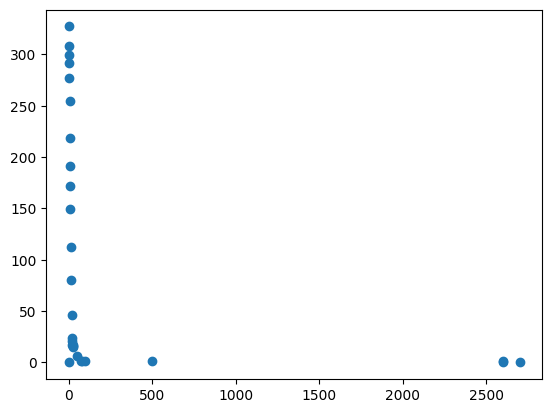

In [87]:
import matplotlib.pyplot as plt
fig, ax = plt.subplots()
#ax.scatter([r[0] for r in r_arr],[r[1] for r in r_arr])

ax.scatter(df[0],df[4])
#ax.set_xscale('log')
#ax.set_yscale('log')
plt.show()

In [88]:
df

,0,1,2,3,4
0,0,0.00000,0,0.00000,0.000000
1,1,327.26394,1,327.26394,327.263940
2,2,635.77016,1,308.50622,308.506220
3,3,935.10458,1,299.33442,299.334420
4,4,1226.97032,1,291.86574,291.865740
5,5,1504.08296,1,277.11264,277.112640
6,6,1758.37102,1,254.28806,254.288060
7,7,1977.09636,1,218.72534,218.725340
8,8,2168.68178,1,191.58542,191.585420
9,9,2340.68046,1,171.99868,171.998680


In [41]:
speicherkap

2700

In [66]:
delta=wetter['PV']+wetter['Wind']-wetter['WP']-wetter['Haus']

In [85]:
import time
start_time = time.time()
f=0
a=[]
for i in range(len(delta)):
    f+=delta.iloc[i]
    #print(f"Row {i}: {delta.iloc[i]}") 
print("--- %s seconds ---" % (time.time() - start_time))

start_time = time.time()

for i in delta.index:  # Here, index defaults to 0, 1, 2
    f+=delta.loc[i]
print("--- %s seconds ---" % (time.time() - start_time))

start_time = time.time()
r_arr=[]
liste=[0,1,2,3,4,5,6,7,8,9,10,12,15,20,21,22,23,24,25,26,50,75,80,100,500,2599,2600,2700]
for speicherkap in liste:
    speicherstand=0
    for n in range(2):
        a_speicherstand=[]
        a_speicherverbrauch=[]
        for change_speicher in delta:
            speicher_alt=speicherstand
            speicherstand=max(min(change_speicher+speicherstand,speicherkap),0)
            verbrauch_speicher=max(speicher_alt-speicherstand,0)
            a_speicherstand.append(speicherstand)
            a_speicherverbrauch.append(verbrauch_speicher)
    r_arr.append([speicherkap,round(sum(a_speicherverbrauch),6)])            
print("--- %s seconds ---" % (time.time() - start_time))

--- 0.0500035285949707 seconds ---
--- 0.10999751091003418 seconds ---
--- 0.4230353832244873 seconds ---


In [64]:
start_time = time.time()
n=0
for i in range(100000):
    n+=1
    f=1 if 1>0 else 2
    #f=min(1,2)
print("--- %s seconds ---" % (time.time() - start_time))

--- 0.013998270034790039 seconds ---


In [58]:
agf={'PV':'sum','WP':'sum','Haus':'sum','Wind':'sum','Netz +':'sum','Netz -':'sum','VerbrauchSpeicher':'sum','Einspeicher':'sum','Speicher':["min", "max"]}
cols=['PV','WP','Haus','Wind','Netz +','Netz -','VerbrauchSpeicher','Einspeicher','Speicher']
pd.pivot_table(df,index='Monat',values=cols, aggfunc=agf)

KeyError: 'PV'

In [72]:
b.apply(lambda x:[y if y >= 0 else 0 for y in x])

AttributeError: 'list' object has no attribute 'apply'

In [12]:
row.iloc[11]+row.iloc[13]-row.iloc[12]-row.iloc[14]

-1128.8653999999995